# Day 5 - Logistic Regression Baseline

## Objective

The objective of Day 5 is to establish a baseline machine learning model for telecom network anomaly detection using Logistic Regression.

The model will be trained using the 64 engineered numerical features created from the TelecomTS KPI time-series data. Performance will be evaluated using precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [2]:
dataset = load_dataset(
    "AliMaatouk/TelecomTS",
    data_files={"full": "**/chunked.jsonl"}
)

data = dataset["full"]

print("Dataset type:", type(data))
print("Number of samples:", len(data))

README.md:   0%|          | 0.00/6.02k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

chunked.jsonl:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

chunked.jsonl:   0%|          | 0.00/6.53M [00:00<?, ?B/s]

...

normal/stationary/Zone_C/no_congestion/Y(…): downloading bytes:           |  0.00B            

normal/stationary/Zone_C/congestion/Twit(…): downloading bytes:           |  0.00B            

normal/stationary/Zone_C/no_congestion/T(…): downloading bytes:           |  0.00B            

Generating full split: 0 examples [00:00, ? examples/s]

Dataset type: <class 'datasets.arrow_dataset.Dataset'>
Number of samples: 32000


In [3]:
numeric_kpis = [
    "RSRP",
    "DL_BLER",
    "DL_MCS",
    "UL_BLER",
    "UL_MCS",
    "UL_NPRB",
    "UL_SNR",
    "TX_Bytes",
    "RX_Bytes",
    "Estimated_UL_Buffer",
    "PRBs_DL_Current",
    "PRBs_UL_Current",
    "PRB_Utilization_DL",
    "PRB_Utilization_UL",
    "UL_NumberOfPackets",
    "DL_NumberOfPackets"
]

print("Number of numerical KPIs:", len(numeric_kpis))

Number of numerical KPIs: 16


In [4]:
def extract_features(sample):
    features = {}

    for kpi in numeric_kpis:
        values = np.array(sample["KPIs"][kpi])

        features[f"{kpi}_mean"] = values.mean()
        features[f"{kpi}_std"] = values.std()
        features[f"{kpi}_min"] = values.min()
        features[f"{kpi}_max"] = values.max()

    return features

In [5]:
all_features = []

for i in range(len(data)):
    sample_features = extract_features(data[i])
    all_features.append(sample_features)

print("Total samples processed:", len(all_features))
print("Features per sample:", len(all_features[0]))

Total samples processed: 32000
Features per sample: 64


In [6]:
df = pd.DataFrame(all_features)

print("Feature dataset shape:", df.shape)
df.head()

Feature dataset shape: (32000, 64)


,RSRP_mean,RSRP_std,RSRP_min,RSRP_max,DL_BLER_mean,DL_BLER_std,DL_BLER_min,DL_BLER_max,DL_MCS_mean,DL_MCS_std,...,PRB_Utilization_UL_min,PRB_Utilization_UL_max,UL_NumberOfPackets_mean,UL_NumberOfPackets_std,UL_NumberOfPackets_min,UL_NumberOfPackets_max,DL_NumberOfPackets_mean,DL_NumberOfPackets_std,DL_NumberOfPackets_min,DL_NumberOfPackets_max
0,-73.232266,0.495679,-75.0,-73.0,0.010302,0.015408,0.000000,0.059794,7.0,0.0,...,0.0472,4.7924,76.273438,26.976180,20.0,189.0,282.312500,299.763807,0.0,1926.0
1,-73.000000,0.000000,-73.0,-73.0,0.008302,0.013705,0.000010,0.061595,7.0,0.0,...,0.0944,3.9341,71.070312,16.495825,32.0,131.0,270.632812,278.073587,0.0,1706.0
2,-73.000000,0.000000,-73.0,-73.0,0.011597,0.016540,0.000000,0.065248,7.0,0.0,...,0.0472,6.4814,75.921875,26.423122,18.0,195.0,298.101562,247.815261,0.0,1821.0
3,-73.143243,0.392053,-75.0,-73.0,0.013444,0.014954,0.001104,0.065243,7.0,0.0,...,0.0944,3.8395,73.875000,20.186629,39.0,177.0,283.750000,228.396961,0.0,952.0
4,-74.000000,0.000000,-74.0,-74.0,0.008212,0.014711,0.000000,0.060280,7.0,0.0,...,0.3963,4.3586,77.101562,24.352823,36.0,190.0,285.234375,242.676530,0.0,1375.0


In [7]:
target = []

for i in range(len(data)):
    label = data[i]["labels"]["anomaly_present"]

    if label == "Yes":
        target.append(1)
    else:
        target.append(0)

df["target"] = target

print(df.shape)

(32000, 65)


In [8]:
print(df["target"].value_counts())

target
0    30765
1     1235
Name: count, dtype: int64


In [ ]:
print(df["target"].value_counts(normalize=True) * 100)

In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32000, 64)
y shape: (32000,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (25600, 64)
Testing set: (6400, 64)


In [12]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
target
0    24612
1      988
Name: count, dtype: int64

Testing class distribution:
target
0    6153
1     247
Name: count, dtype: int64


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (25600, 64)
Testing scaled shape: (6400, 64)


In [14]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [15]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated.")
print("Number of predictions:", len(y_pred))

Predictions generated.
Number of predictions: 6400


In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Anomaly"]
))

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      6153
     Anomaly       0.95      0.74      0.83       247

    accuracy                           0.99      6400
   macro avg       0.97      0.87      0.91      6400
weighted avg       0.99      0.99      0.99      6400



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6144    9]
 [  64  183]]


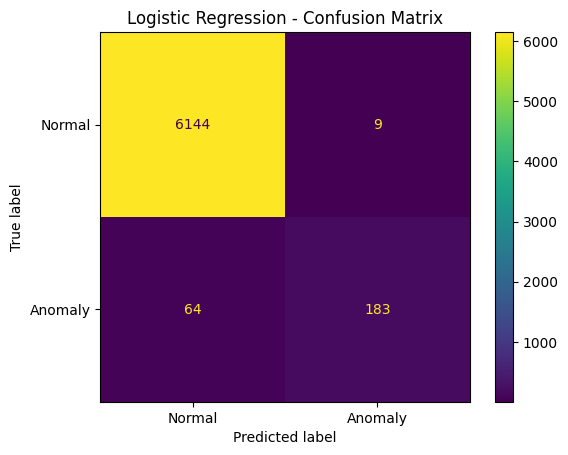

In [18]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [19]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9785391543968875


In [21]:
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Precision": [report["1"]["precision"]],
    "Recall": [report["1"]["recall"]],
    "F1": [report["1"]["f1-score"]],
    "ROC-AUC": [roc_auc]
})

results

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.953125,0.740891,0.833713,0.978539


In [22]:
results.to_csv(
    "day5_logistic_regression_results.csv",
    index=False
)

print("Results saved.")

Results saved.


## Day 5 Observations

A Logistic Regression model was established as the baseline classifier for telecom network anomaly detection.

The model was trained using 64 engineered statistical features derived from 16 numerical telecom KPIs. The dataset was divided into training and testing subsets using stratified sampling, and feature standardization was applied using parameters learned only from the training data.

The baseline model was evaluated using precision, recall, F1-score, confusion matrix, and ROC-AUC.

The anomaly class represents a smaller proportion of the dataset, so accuracy alone is not considered sufficient for evaluating the model. Particular attention was given to anomaly-class precision, recall, F1-score, and ROC-AUC.

The obtained baseline results will be used as a reference for evaluating more advanced models in subsequent experiments.